<a href="https://colab.research.google.com/github/kinchittrivedi/Kaggle/blob/main/Practice_model_from_scratch.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
# IMPORTANT: SOME KAGGLE DATA SOURCES ARE PRIVATE
# RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES.

#import kagglehub
#kagglehub.login()

In [3]:
titanic_path = kagglehub.competition_download('titanic')
print('Data source import complete.')

100%|██████████| 34.1k/34.1k [00:00<00:00, 26.9MB/s]

Extracting files...
Data source import complete.


In [4]:
!pip install kaggle
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [5]:
import os
from pathlib import Path

iskaggle = os.environ.get('KAGGLE_KERNEL_RUN_TYPE', '')
if iskaggle:
    path = Path('../input/titanic')
else:
  path = Path('titanic')
  if not path.exists():
    import zipfile, kaggle
    kaggle.api.competition_download_cli(str(path))
    zipfile.ZipFile(f'{path}.zip').extractall(path)


100%|██████████| 34.1k/34.1k [00:00<00:00, 32.8MB/s]

In [6]:
import torch, numpy as np, pandas as pd
np.set_printoptions(linewidth = 120)
torch.set_printoptions(linewidth = 120, sci_mode = False, edgeitems=7)
pd.set_option('display.width',120)

In [7]:
df = pd.read_csv(path/'train.csv')
df

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C


In [8]:
df.isna().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


In [9]:
df.mode()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0.0,3.0,"Abbing, Mr. Anthony",male,24.0,0.0,0.0,1601,8.05,B96 B98,S
1,2,NaN,NaN,"Abbott, Mr. Rossmore Edward",NaN,NaN,NaN,NaN,347082,NaN,C23 C25 C27,NaN
2,3,NaN,NaN,"Abbott, Mrs. Stanton (Rosa Hunt)",NaN,NaN,NaN,NaN,CA. 2343,NaN,G6,NaN
3,4,NaN,NaN,"Abelson, Mr. Samuel",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,5,NaN,NaN,"Abelson, Mrs. Samuel (Hannah Wizosky)",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,NaN,NaN,"de Mulder, Mr. Theodore",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
887,888,NaN,NaN,"de Pelsmaeker, Mr. Alfons",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
888,889,NaN,NaN,"del Carlo, Mr. Sebastiano",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
889,890,NaN,NaN,"van Billiard, Mr. Austin Blyler",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [10]:
modes = df.mode().iloc()[0]
modes

,0
PassengerId,1
Survived,0.0
Pclass,3.0
Name,"Abbing, Mr. Anthony"
Sex,male
Age,24.0
SibSp,0.0
Parch,0.0
Ticket,1601
Fare,8.05


In [11]:
df.fillna(modes, inplace = True)

In [12]:
df.isna().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,0
SibSp,0
Parch,0
Ticket,0
Fare,0


In [13]:
df.describe(include= np.number)

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,28.566970,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,13.199572,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,22.000000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,24.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,35.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


<Axes: >

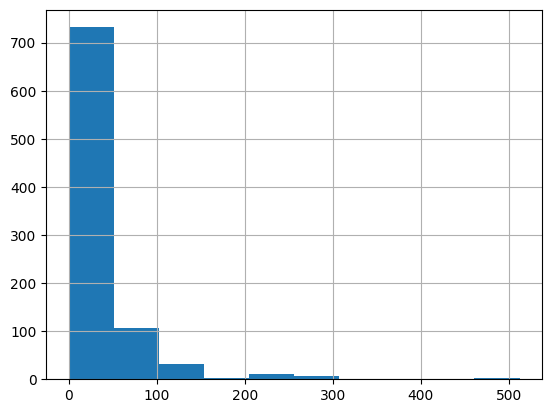

In [14]:
df['Fare'].hist()

<Axes: >

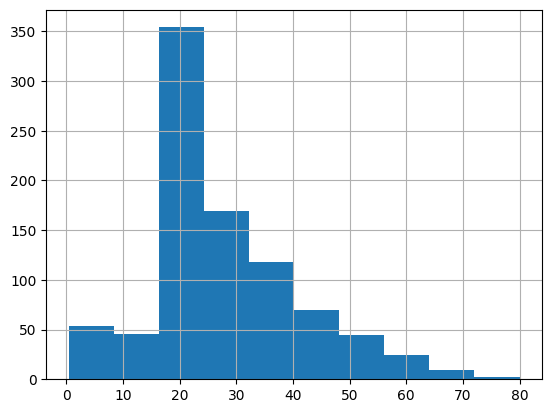

In [15]:
df['Age'].hist()

<Axes: >

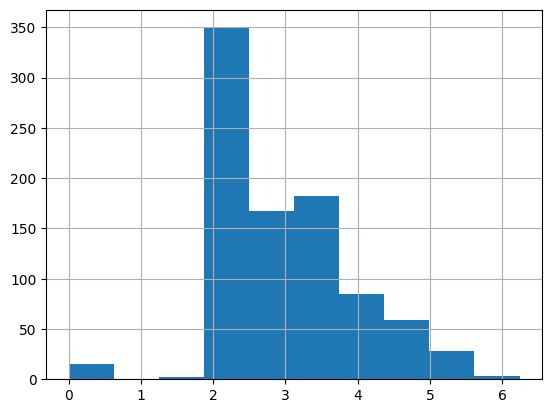

In [16]:
df['Logfare'] = np.log(df['Fare']+1)
df['Logfare'].hist()

In [17]:
df.describe(include= object)

,Name,Sex,Ticket,Cabin,Embarked
count,891,891,891,891,891
unique,891,2,681,147,3
top,"Dooley, Mr. Patrick",male,347082,B96 B98,S
freq,1,577,7,691,646


In [18]:
df = pd.get_dummies(df, columns = ['Sex', 'Embarked', 'Pclass'])
df.columns

Index(['PassengerId', 'Survived', 'Name', 'Age', 'SibSp', 'Parch', 'Ticket', 'Fare', 'Cabin', 'Logfare', 'Sex_female',
       'Sex_male', 'Embarked_C', 'Embarked_Q', 'Embarked_S', 'Pclass_1', 'Pclass_2', 'Pclass_3'],
      dtype='object')

In [19]:
added_cols = ['Sex_female', 'Sex_male', 'Embarked_C', 'Embarked_Q', 'Embarked_S', 'Pclass_1', 'Pclass_2', 'Pclass_3']
df[added_cols].head()

,Sex_female,Sex_male,Embarked_C,Embarked_Q,Embarked_S,Pclass_1,Pclass_2,Pclass_3
0,False,True,False,False,True,False,False,True
1,True,False,True,False,False,True,False,False
2,True,False,False,False,True,False,False,True
3,True,False,False,False,True,True,False,False
4,False,True,False,False,True,False,False,True


In [20]:
df.describe()

,PassengerId,Survived,Age,SibSp,Parch,Fare,Logfare
count,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,28.566970,0.523008,0.381594,32.204208,2.962246
std,257.353842,0.486592,13.199572,1.102743,0.806057,49.693429,0.969048
min,1.000000,0.000000,0.420000,0.000000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,22.000000,0.000000,0.000000,7.910400,2.187218
50%,446.000000,0.000000,24.000000,0.000000,0.000000,14.454200,2.737881
75%,668.500000,1.000000,35.000000,1.000000,0.000000,31.000000,3.465736
max,891.000000,1.000000,80.000000,8.000000,6.000000,512.329200,6.240917


In [21]:
from torch import tensor
t_dep = tensor(df['Survived'])

In [22]:
indep_cols = ['Age', 'SibSp', 'Parch', 'Logfare'] + added_cols
t_indep = tensor(df[indep_cols].astype(float).values,dtype = float)
t_indep


tensor([[22.0000,  1.0000,  0.0000,  2.1102,  0.0000,  1.0000,  0.0000,  0.0000,  1.0000,  0.0000,  0.0000,  1.0000],
        [38.0000,  1.0000,  0.0000,  4.2806,  1.0000,  0.0000,  1.0000,  0.0000,  0.0000,  1.0000,  0.0000,  0.0000],
        [26.0000,  0.0000,  0.0000,  2.1889,  1.0000,  0.0000,  0.0000,  0.0000,  1.0000,  0.0000,  0.0000,  1.0000],
        [35.0000,  1.0000,  0.0000,  3.9908,  1.0000,  0.0000,  0.0000,  0.0000,  1.0000,  1.0000,  0.0000,  0.0000],
        [35.0000,  0.0000,  0.0000,  2.2028,  0.0000,  1.0000,  0.0000,  0.0000,  1.0000,  0.0000,  0.0000,  1.0000],
        [24.0000,  0.0000,  0.0000,  2.2469,  0.0000,  1.0000,  0.0000,  1.0000,  0.0000,  0.0000,  0.0000,  1.0000],
        [54.0000,  0.0000,  0.0000,  3.9677,  0.0000,  1.0000,  0.0000,  0.0000,  1.0000,  1.0000,  0.0000,  0.0000],
        ...,
        [25.0000,  0.0000,  0.0000,  2.0857,  0.0000,  1.0000,  0.0000,  0.0000,  1.0000,  0.0000,  0.0000,  1.0000],
        [39.0000,  0.0000,  5.0000,  3.4054

In [23]:
t_indep.shape

torch.Size([891, 12])

In [24]:
torch.manual_seed(30)
n_coeff = t_indep.shape[1]
coeffs = torch.rand(n_coeff)-0.5
coeffs

tensor([ 0.4007,  0.2464, -0.0284,  0.3738,  0.2403,  0.2840,  0.3946,  0.1238, -0.0724,  0.3421,  0.2454,  0.1181])

In [25]:
t_indep*coeffs

tensor([[ 8.8164,  0.2464, -0.0000,  0.7887,  0.0000,  0.2840,  0.0000,  0.0000, -0.0724,  0.0000,  0.0000,  0.1181],
        [15.2283,  0.2464, -0.0000,  1.5999,  0.2403,  0.0000,  0.3946,  0.0000, -0.0000,  0.3421,  0.0000,  0.0000],
        [10.4193,  0.0000, -0.0000,  0.8181,  0.2403,  0.0000,  0.0000,  0.0000, -0.0724,  0.0000,  0.0000,  0.1181],
        [14.0260,  0.2464, -0.0000,  1.4916,  0.2403,  0.0000,  0.0000,  0.0000, -0.0724,  0.3421,  0.0000,  0.0000],
        [14.0260,  0.0000, -0.0000,  0.8233,  0.0000,  0.2840,  0.0000,  0.0000, -0.0724,  0.0000,  0.0000,  0.1181],
        [ 9.6179,  0.0000, -0.0000,  0.8398,  0.0000,  0.2840,  0.0000,  0.1238, -0.0000,  0.0000,  0.0000,  0.1181],
        [21.6402,  0.0000, -0.0000,  1.4830,  0.0000,  0.2840,  0.0000,  0.0000, -0.0724,  0.3421,  0.0000,  0.0000],
        ...,
        [10.0186,  0.0000, -0.0000,  0.7796,  0.0000,  0.2840,  0.0000,  0.0000, -0.0724,  0.0000,  0.0000,  0.1181],
        [15.6290,  0.0000, -0.1419,  1.2728

In [26]:
val, indices = t_indep.max(dim=0)
t_indep = t_indep/val
t_indep

tensor([[0.2750, 0.1250, 0.0000, 0.3381, 0.0000, 1.0000, 0.0000, 0.0000, 1.0000, 0.0000, 0.0000, 1.0000],
        [0.4750, 0.1250, 0.0000, 0.6859, 1.0000, 0.0000, 1.0000, 0.0000, 0.0000, 1.0000, 0.0000, 0.0000],
        [0.3250, 0.0000, 0.0000, 0.3507, 1.0000, 0.0000, 0.0000, 0.0000, 1.0000, 0.0000, 0.0000, 1.0000],
        [0.4375, 0.1250, 0.0000, 0.6395, 1.0000, 0.0000, 0.0000, 0.0000, 1.0000, 1.0000, 0.0000, 0.0000],
        [0.4375, 0.0000, 0.0000, 0.3530, 0.0000, 1.0000, 0.0000, 0.0000, 1.0000, 0.0000, 0.0000, 1.0000],
        [0.3000, 0.0000, 0.0000, 0.3600, 0.0000, 1.0000, 0.0000, 1.0000, 0.0000, 0.0000, 0.0000, 1.0000],
        [0.6750, 0.0000, 0.0000, 0.6358, 0.0000, 1.0000, 0.0000, 0.0000, 1.0000, 1.0000, 0.0000, 0.0000],
        ...,
        [0.3125, 0.0000, 0.0000, 0.3342, 0.0000, 1.0000, 0.0000, 0.0000, 1.0000, 0.0000, 0.0000, 1.0000],
        [0.4875, 0.0000, 0.8333, 0.5456, 1.0000, 0.0000, 0.0000, 1.0000, 0.0000, 0.0000, 0.0000, 1.0000],
        [0.3375, 0.0000, 0.0000, 

In [27]:
t_indep*coeffs

tensor([[ 0.1102,  0.0308, -0.0000,  0.1264,  0.0000,  0.2840,  0.0000,  0.0000, -0.0724,  0.0000,  0.0000,  0.1181],
        [ 0.1904,  0.0308, -0.0000,  0.2564,  0.2403,  0.0000,  0.3946,  0.0000, -0.0000,  0.3421,  0.0000,  0.0000],
        [ 0.1302,  0.0000, -0.0000,  0.1311,  0.2403,  0.0000,  0.0000,  0.0000, -0.0724,  0.0000,  0.0000,  0.1181],
        [ 0.1753,  0.0308, -0.0000,  0.2390,  0.2403,  0.0000,  0.0000,  0.0000, -0.0724,  0.3421,  0.0000,  0.0000],
        [ 0.1753,  0.0000, -0.0000,  0.1319,  0.0000,  0.2840,  0.0000,  0.0000, -0.0724,  0.0000,  0.0000,  0.1181],
        [ 0.1202,  0.0000, -0.0000,  0.1346,  0.0000,  0.2840,  0.0000,  0.1238, -0.0000,  0.0000,  0.0000,  0.1181],
        [ 0.2705,  0.0000, -0.0000,  0.2376,  0.0000,  0.2840,  0.0000,  0.0000, -0.0724,  0.3421,  0.0000,  0.0000],
        ...,
        [ 0.1252,  0.0000, -0.0000,  0.1249,  0.0000,  0.2840,  0.0000,  0.0000, -0.0724,  0.0000,  0.0000,  0.1181],
        [ 0.1954,  0.0000, -0.0237,  0.2039

In [28]:
preds = (t_indep*coeffs).sum(axis = 1)
preds

tensor([0.5971, 1.4544, 0.5473, 0.9551, 0.6370, 0.7808, 1.0618, 0.6127, 0.5613, 1.1870, 0.5042, 0.9991, 0.5618, 0.7403,
        0.4867, 0.8585, 0.8584, 0.7353, 0.6484, 0.9994, 0.8297, 0.7854, 0.6892, 0.9094, 0.5990, 0.6918, 1.0431, 1.0657,
        0.7332, 0.5809, 1.4221, 1.4270, 0.7324, 0.9339, 1.4565, 1.0327, 1.0432, 0.5669, 0.6141, 1.0039, 0.6578, 0.7645,
        1.0478, 1.1413, 0.7082, 0.5819, 0.8449, 0.7324, 1.1655, 0.5827, 0.7052, 0.5652, 1.5139, 0.7867, 1.5897, 0.8894,
        0.6648, 1.0657, 0.6608, 0.7611, 1.0332, 0.9635, 1.0756, 0.6342, 1.3420, 1.1100, 0.7048, 0.5575, 0.6160, 0.6574,
        0.7636, 0.7424, 0.8204, 1.1217, 0.7327, 0.5842, 0.5809, 0.5819, 0.6554, 0.5920, 0.5778, 0.6158, 0.7326, 0.9259,
        0.6447, 0.7128, 0.6401, 0.5819, 1.0420, 0.5819, 0.6069, 0.5605, 1.0623, 0.6653, 0.7517, 0.5819, 1.5904, 1.3806,
        0.7692, 0.8555, 0.5571, 0.5809, 0.9153, 0.6308, 0.7078, 0.6009, 0.5204, 0.5800, 0.6510, 0.8264, 1.0269, 1.0204,
        0.5719, 0.5596, 1.0021, 0.5660, 

In [29]:
loss = torch.abs(preds - t_dep).mean()
loss

tensor(0.5815, dtype=torch.float64)

In [30]:
def calc_preds(coeffs,t_indep): return (t_indep*coeffs).sum(axis = 1)
def calc_loss(coeffs, t_indep,t_dep): return torch.abs(calc_preds(coeffs, t_indep) - t_dep).mean()

In [31]:
coeffs.requires_grad_()

tensor([ 0.4007,  0.2464, -0.0284,  0.3738,  0.2403,  0.2840,  0.3946,  0.1238, -0.0724,  0.3421,  0.2454,  0.1181],
       requires_grad=True)

In [32]:
loss = calc_loss(coeffs,t_indep,t_dep)
loss

tensor(0.5815, dtype=torch.float64, grad_fn=<MeanBackward0>)

In [33]:
loss.backward()

In [34]:
coeffs.grad

tensor([ 0.1916,  0.0376,  0.0221,  0.2167, -0.0157,  0.4860,  0.1684,  0.0213,  0.2806,  0.1190,  0.0314,  0.3199])

In [36]:
loss = calc_loss(coeffs,t_indep,t_dep)
loss.backward()
coeffs.grad



tensor([ 0.5748,  0.1128,  0.0662,  0.6500, -0.0471,  1.4579,  0.5051,  0.0640,  0.8418,  0.3569,  0.0943,  0.9596])

In [37]:
loss = calc_loss(coeffs, t_indep, t_dep)
loss.backward()
with torch.no_grad():
    coeffs.sub_(coeffs.grad * 0.1)
    coeffs.grad.zero_()
    print(calc_loss(coeffs, t_indep, t_dep))

tensor(0.3883, dtype=torch.float64)


In [38]:
from fastai.data.transforms import RandomSplitter
trn_split,val_split=RandomSplitter(seed=42)(df)
len(trn_split),len(val_split)

(713, 178)

In [39]:
trn_indep,val_indep = t_indep[trn_split],t_indep[val_split]
trn_dep,val_dep = t_dep[trn_split],t_dep[val_split]
len(trn_indep),len(val_indep), len(trn_dep),len(val_dep)

(713, 178, 713, 178)

In [51]:
def update_coeffs(coeffs, lr):
  coeffs.sub_(coeffs.grad * lr)
  coeffs.grad.zero_()

In [53]:
def one_epoch(coeffs, lr):
  loss = calc_loss(coeffs, trn_indep, trn_dep)
  loss.backward()
  with torch.no_grad():update_coeffs(coeffs, lr)
  print(f'{loss: .3f}',end=';')

In [158]:
def init_coeffs():return (torch.rand(n_coeff)-0.5).requires_grad_()

In [100]:
def train_model(epochs = 30, lr = 0.01):
  torch.manual_seed(42)
  coeffs = init_coeffs()
  for i in range(epochs):one_epoch(coeffs, lr=lr)
  return coeffs

In [101]:
coeffs = train_model(18, lr=0.2)

 0.451; 0.448; 0.445; 0.442; 0.440; 0.437; 0.435; 0.432; 0.430; 0.428; 0.425; 0.423; 0.421; 0.419; 0.417; 0.415; 0.414; 0.412;

In [102]:
def show_coeffs(): return dict(zip(indep_cols, coeffs.requires_grad_(False)))
show_coeffs()

{'Age': tensor(-0.5013, dtype=torch.float64),
 'SibSp': tensor(-0.4464, dtype=torch.float64),
 'Parch': tensor(-0.3765, dtype=torch.float64),
 'Logfare': tensor(-0.4799, dtype=torch.float64),
 'Sex_female': tensor(0.1466, dtype=torch.float64),
 'Sex_male': tensor(-0.2889, dtype=torch.float64),
 'Embarked_C': tensor(0.4680, dtype=torch.float64),
 'Embarked_Q': tensor(0.4123, dtype=torch.float64),
 'Embarked_S': tensor(-0.5581, dtype=torch.float64),
 'Pclass_1': tensor(-0.3234, dtype=torch.float64),
 'Pclass_2': tensor(-0.3455, dtype=torch.float64),
 'Pclass_3': tensor(-0.3113, dtype=torch.float64)}

In [103]:
preds = calc_preds(coeffs, val_indep)
preds

tensor([0.4660, 0.3764, 0.3906, 0.1629, 0.1748, 0.1546, 0.5026, 0.2432, 0.1339, 0.4482, 0.1784, 0.3508, 0.1833, 0.4823,
        0.1785, 0.1535, 0.1379, 0.2262, 0.1557, 0.2513, 0.1859, 0.1448, 0.3931, 0.1735, 0.1909, 0.3448, 0.2613, 0.1402,
        0.1917, 0.4826, 0.2318, 0.1787, 0.1907, 0.1796, 0.4566, 0.2057, 0.1495, 0.4536, 0.1857, 0.2491, 0.1825, 0.1857,
        0.1418, 0.4394, 0.1895, 0.1710, 0.1635, 0.1685, 0.3781, 0.2645, 0.2821, 0.1282, 0.1381, 0.1861, 0.1761, 0.1707,
        0.3763, 0.1604, 0.1886, 0.1743, 0.3565, 0.1853, 0.1261, 0.1887, 0.2072, 0.1545, 0.1757, 0.1610, 0.3159, 0.2236,
        0.1840, 0.4534, 0.1716, 0.1840, 0.1716, 0.1938, 0.1857, 0.1405, 0.1803, 0.1544, 0.1602, 0.3761, 0.1869, 0.1868,
        0.2213, 0.3116, 0.3375, 0.2022, 0.4478, 0.1766, 0.1779, 0.1857, 0.4363, 0.3817, 0.4733, 0.3557, 0.1500, 0.4355,
        0.4857, 0.3859, 0.1740, 0.4826, 0.1785, 0.1803, 0.1502, 0.1599, 0.1784, 0.1963, 0.3308, 0.1742, 0.2071, 0.2316,
        0.1701, 0.4076, 0.1857, 0.3837, 

In [104]:
results = val_dep.bool()==(preds>0.5)
results[:16]

tensor([False,  True,  True,  True,  True,  True,  True, False,  True, False, False, False, False, False,  True, False])

In [105]:
results.float().mean()

tensor(0.6011)

In [106]:
def acc(coeffs): return (val_dep.bool()==(calc_preds(coeffs,val_indep)>0.5)).float().mean()
acc(coeffs)


tensor(0.6011)

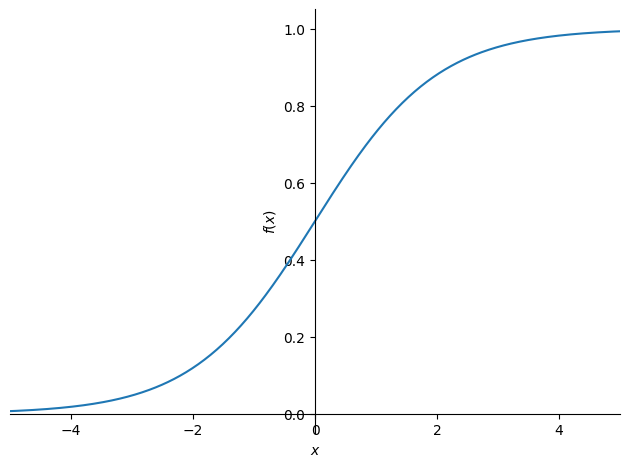

In [81]:
import sympy
from sympy import Symbol, exp
x = Symbol('x')
sympy.plot(1/(1+exp(-x)), xlim=(-5,5));

In [107]:
def calc_preds(coeffs, indeps): return torch.sigmoid((indeps*coeffs).sum(axis =1))

In [108]:
coeffs = train_model(epochs = 30,lr=100)

 0.451; 0.329; 0.313; 0.227; 0.204; 0.198; 0.197; 0.197; 0.196; 0.196; 0.196; 0.195; 0.195; 0.195; 0.195; 0.195; 0.195; 0.195; 0.195; 0.194; 0.194; 0.194; 0.194; 0.194; 0.194; 0.194; 0.194; 0.194; 0.194; 0.194;

In [109]:
acc(coeffs)

tensor(0.8258)

In [110]:
show_coeffs()

{'Age': tensor(-1.2009, dtype=torch.float64),
 'SibSp': tensor(-1.4959, dtype=torch.float64),
 'Parch': tensor(-1.0201, dtype=torch.float64),
 'Logfare': tensor(0.2932, dtype=torch.float64),
 'Sex_female': tensor(8.0226, dtype=torch.float64),
 'Sex_male': tensor(-8.6182, dtype=torch.float64),
 'Embarked_C': tensor(1.9495, dtype=torch.float64),
 'Embarked_Q': tensor(2.1937, dtype=torch.float64),
 'Embarked_S': tensor(-4.2743, dtype=torch.float64),
 'Pclass_1': tensor(2.5866, dtype=torch.float64),
 'Pclass_2': tensor(2.1190, dtype=torch.float64),
 'Pclass_3': tensor(-6.1392, dtype=torch.float64)}

In [111]:
(val_indep*coeffs).sum(axis=1)

tensor([ 12.0967, -12.8221, -13.0692, -10.8413, -11.0249, -11.3258,   3.7282,   5.5709, -20.1399,   3.2637, -19.4093,
        -13.3942, -19.3315,   3.8194, -19.4475, -10.8257, -11.1259,   5.4767, -11.2042,  -2.7496, -19.2894, -10.9908,
         11.8379,   4.8164, -19.2340, -12.9595,  -2.6457, -11.0809, -19.1804,   3.8187,   5.3809,  -3.7243, -19.2143,
        -19.3861,  12.0067,  -3.3457, -10.8444,  12.3982, -19.2885,  -2.8504, -10.9441, -19.2885, -11.5067,  12.2826,
        -19.2285,  -3.6824, -19.2317, -19.5076, -12.8266,  -2.6220,  -4.6605, -20.2600, -20.0914, -19.3091, -11.0492,
        -11.1392, -12.8221, -19.6273, -19.2435, -19.3262,  -4.3747, -19.3759, -11.3456, -19.2442,   5.1745, -10.5864,
        -11.0099, -19.4657, -13.3895,   5.3173, -19.3194,   3.2636, -11.1242, -19.2816, -10.5115, -19.1699, -19.2885,
        -10.8515, -10.9349, -11.3489, -11.1593,  11.7913, -19.2743, -19.2929,   5.2314,  -5.2758,  -4.3185,   5.8230,
         11.6350, -10.9949, -19.4070, -19.2885,  12.3281

In [112]:
val_indep @ coeffs

tensor([ 12.0967, -12.8221, -13.0692, -10.8413, -11.0249, -11.3258,   3.7282,   5.5709, -20.1399,   3.2637, -19.4093,
        -13.3942, -19.3315,   3.8194, -19.4475, -10.8257, -11.1259,   5.4767, -11.2042,  -2.7496, -19.2894, -10.9908,
         11.8379,   4.8164, -19.2340, -12.9595,  -2.6457, -11.0809, -19.1804,   3.8187,   5.3809,  -3.7243, -19.2143,
        -19.3861,  12.0067,  -3.3457, -10.8444,  12.3982, -19.2885,  -2.8504, -10.9441, -19.2885, -11.5067,  12.2826,
        -19.2285,  -3.6824, -19.2317, -19.5076, -12.8266,  -2.6220,  -4.6605, -20.2600, -20.0914, -19.3091, -11.0492,
        -11.1392, -12.8221, -19.6273, -19.2435, -19.3262,  -4.3747, -19.3759, -11.3456, -19.2442,   5.1745, -10.5864,
        -11.0099, -19.4657, -13.3895,   5.3173, -19.3194,   3.2636, -11.1242, -19.2816, -10.5115, -19.1699, -19.2885,
        -10.8515, -10.9349, -11.3489, -11.1593,  11.7913, -19.2743, -19.2929,   5.2314,  -5.2758,  -4.3185,   5.8230,
         11.6350, -10.9949, -19.4070, -19.2885,  12.3281

In [163]:
def calc_preds(coeffs, indeps): return torch.sigmoid((indeps@coeffs))

In [164]:
def init_coeffs(): return (torch.rand(n_coeff, 1) * 0.1).requires_grad_()

In [166]:
trn_dep = trn_dep[:,None]
val_dep = val_dep[:,None]
trn_indep = trn_indep.float()
val_indep = val_indep.float()

In [167]:
#def init_coeffs(): return (torch.rand(n_coeff, 1, dtype=torch.float64) * 0.1).requires_grad_()

coeffs = train_model(lr=100)

 0.516; 0.379; 0.379; 0.379; 0.379; 0.379; 0.379; 0.379; 0.379; 0.379; 0.379; 0.379; 0.379; 0.379; 0.379; 0.379; 0.379; 0.379; 0.379; 0.379; 0.379; 0.379; 0.379; 0.379; 0.379; 0.379; 0.379; 0.379; 0.379; 0.379;

In [161]:
acc(coeffs)

tensor(0.5955)

In [168]:
def init_coeffs(n_hidden=20):
    layer1 = (torch.rand(n_coeff, n_hidden)-0.5)/n_hidden
    layer2 = torch.rand(n_hidden, 1)-0.3
    const = torch.rand(1)[0]
    return layer1.requires_grad_(),layer2.requires_grad_(),const.requires_grad_()

In [170]:
import torch.nn.functional as F

def calc_preds(coeffs, indeps):
    l1,l2,const = coeffs
    res = F.relu(indeps@l1)
    res = res@l2 + const
    return torch.sigmoid(res)

In [171]:
def update_coeffs(coeffs, lr):
    for layer in coeffs:
        layer.sub_(layer.grad * lr)
        layer.grad.zero_()

In [172]:
coeffs = train_model(lr=1.4)

 0.550; 0.545; 0.541; 0.536; 0.531; 0.526; 0.520; 0.513; 0.506; 0.498; 0.490; 0.481; 0.472; 0.462; 0.452; 0.443; 0.434; 0.426; 0.419; 0.413; 0.408; 0.404; 0.401; 0.398; 0.396; 0.394; 0.392; 0.391; 0.390; 0.389;

In [ ]:
def init_coeffs():
    hiddens = [10, 10]  # <-- set this to the size of each hidden layer you want
    sizes = [n_coeff] + hiddens + [1]
    n = len(sizes)
    layers = [(torch.rand(sizes[i], sizes[i+1])-0.3)/sizes[i+1]*4 for i in range(n-1)]
    consts = [(torch.rand(1)[0]-0.5)*0.1 for i in range(n-1)]
    for l in layers+consts: l.requires_grad_()
    return layers,consts

In [ ]:
import torch.nn.functional as F

def calc_preds(coeffs, indeps):
    layers,consts = coeffs
    n = len(layers)
    res = indeps
    for i,l in enumerate(layers):
        res = res@l + consts[i]
        if i!=n-1: res = F.relu(res)
    return torch.sigmoid(res)

In [ ]:
def update_coeffs(coeffs, lr):
    layers,consts = coeffs
    for layer in layers+consts:
        layer.sub_(layer.grad * lr)
        layer.grad.zero_()